# CV Session 26 Summer · Week 2 코드 과제
## Attention & Transformer: 구현에서 비교 실험까지

이번 과제는 크게 두 부분으로 구성됩니다.

1. **Transformer를 바닥부터 구현하기**: <br>
 embedding → positional encoding → attention → encoder/decoder → 전체 모델
  - 코드 내에 빈칸을 채워가면서 구현해보세요!!
2. **직접 구현한 Transformer와 traditional RNN 비교하기**: <br>
IMDB 50,000개 장문 영화 리뷰 데이터에서 성능, 파라미터 수, 학습 시간, 추론 시간, 계산 복잡도를 비교
  - 결과를 보고, text cell에 강의에서 배운 내용과 연결 짓는 질문에 답변해 보세요. 이번 과제의 핵심입니다! (2개의 질문을 비워 두었습니다)

### GOAL

- 각 모듈에서 tensor shape가 어떻게 변하는지 따라가보기
- scaled dot-product attention과 두 종류의 mask가 필요한 이유를 이해
- Transformer의 병렬성과 self-attention의 $O(n^2)$ 비용을 RNN과 실측으로 비교
- 특히 Positional encoding, Multi-headed Self Attention에 집중해서 구현 실습을 해봅시다!! 😃

<br>
- P.S.<br>
AI를 사용하셔도 좋지만, ... 강의 자료와 과제를 마련하는 세션리더(22기 박준영 & 이세훈)의 노력을 생각해서 고민하고 이해하려는 노력을 해봅시다 ㅎㅎ

<br>
<br>

### 주요 참고자료

- [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [Transformer 아키텍처 구현하기 (PyTorch)](https://j2rooong.tistory.com/entry/Pytorch-Transformer-Architecture-%EA%B5%AC%ED%98%84%ED%95%98%EA%B8%B0)
- [Transformer 구현: Positional Encoding](https://code-angie.tistory.com/9)
- [Transformer 구현: Sub Layers](https://code-angie.tistory.com/7#3-position-wise-fully-connected-feed-forward-network)
- [Transformer from Scratch 영상](https://www.youtube.com/watch?v=ISNdQcPhsts)
- [IMDB Large Movie Review Dataset](https://ai.stanford.edu/~amaas/data/sentiment/)
<br>
<br>

### 표기 규칙은 다음과 같습니다

- $B$: batch size, $L$: sequence length, $d_{model}$: embedding dimension
- 코드의 기본 입력 shape: **`(B, L, d_model)`**
- attention 내부 shape: **`(B, h, L, d_k)`**, 단 $d_k=d_{model}/h$


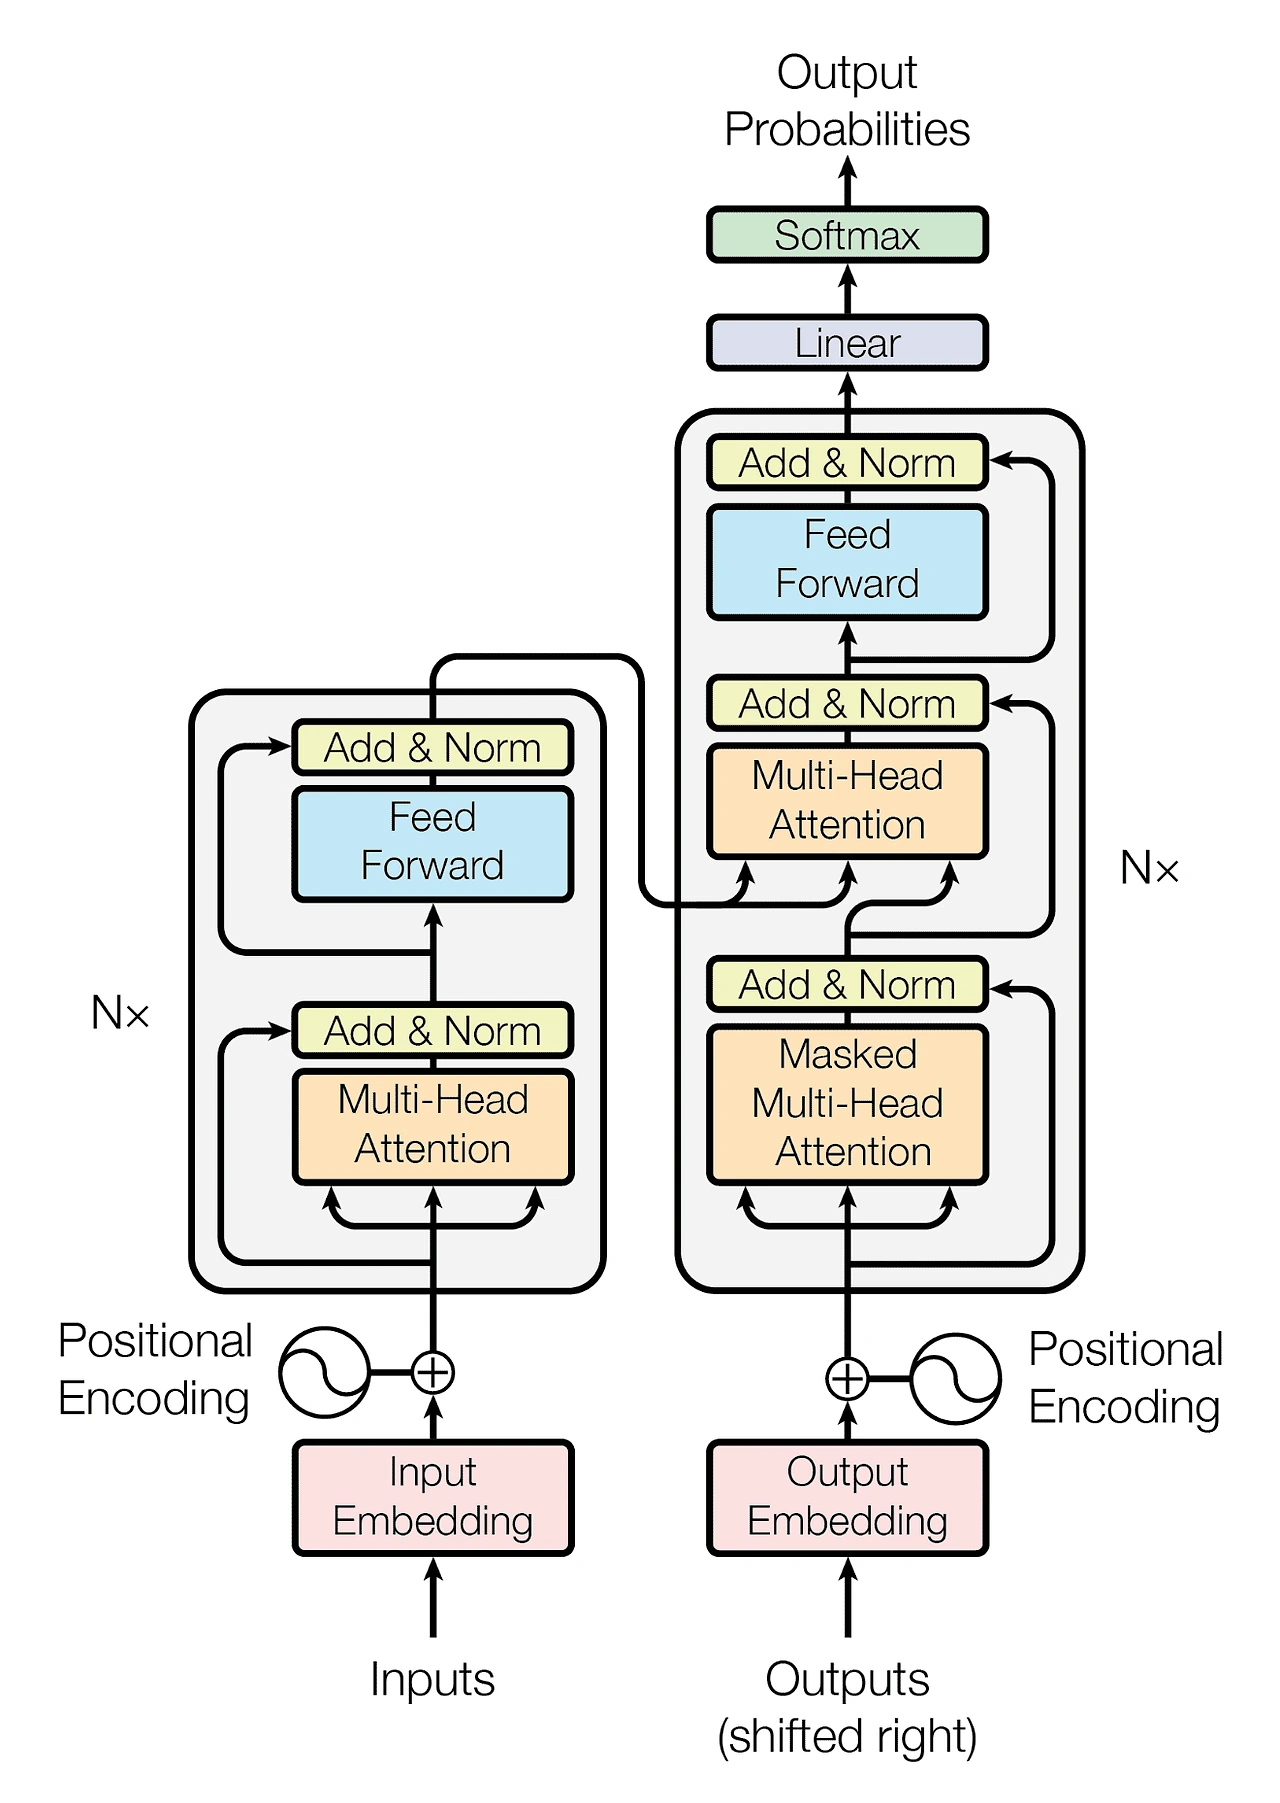

# Part 1. Transformer 구현하기

## 1. Input / Output Embedding

token id는 그 자체로 크기나 거리에 의미가 없는 정수입니다. `nn.Embedding`은 각 id를 $d_{model}$차원의 학습 가능한 벡터로 바꿉니다.

논문에서는 embedding에 $\sqrt{d_{model}}$을 곱합니다. 초기화 직후 embedding의 크기를 positional encoding과 비슷한 scale로 맞추어 두 정보가 더 안정적으로 합쳐지게 하는 장치입니다.

- 입력: `(B, L)` — 정수 token id
- 출력: `(B, L, d_model)` — 실수 embedding


In [1]:
import math
import torch
import torch.nn as nn


class InputEmbeddings(nn.Module):
    def __init__(self, d_model: int, vocab_size: int) -> None:
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.embedding(x) * math.sqrt(self.d_model)


## 2. Positional Encoding

지난 강의에서 언급된 것 처럼, Self-attention만 놓고 보면 입력 token의 순서를 바꾸었을 때 출력도 같은 방식으로 바뀌는 **permutation equivariant** 연산입니다. 즉, 별도의 위치 정보가 없으면 “Junho bites Dog”와 “Dog bites Junho”의 순서를 구별하기 어렵습니다.

(심화) 고정 sinusoidal positional encoding은 위치 $pos$와 차원 index $i$를 다음처럼 변환합니다.

$$PE_{(pos,2i)}=\sin\left(pos\cdot 10000^{-2i/d_{model}}\right)$$

$$PE_{(pos,2i+1)}=\cos\left(pos\cdot 10000^{-2i/d_{model}}\right)$$

서로 다른 주기의 sin/cos가 각 위치에 고유한 패턴을 만들고, 미리 만든 `(1, max_len, d_model)` buffer를 실제 길이만큼 잘라 embedding에 더합니다. buffer는 parameter가 아니므로 gradient로 학습되지 않지만 모델과 함께 저장되고 device도 함께 이동합니다.


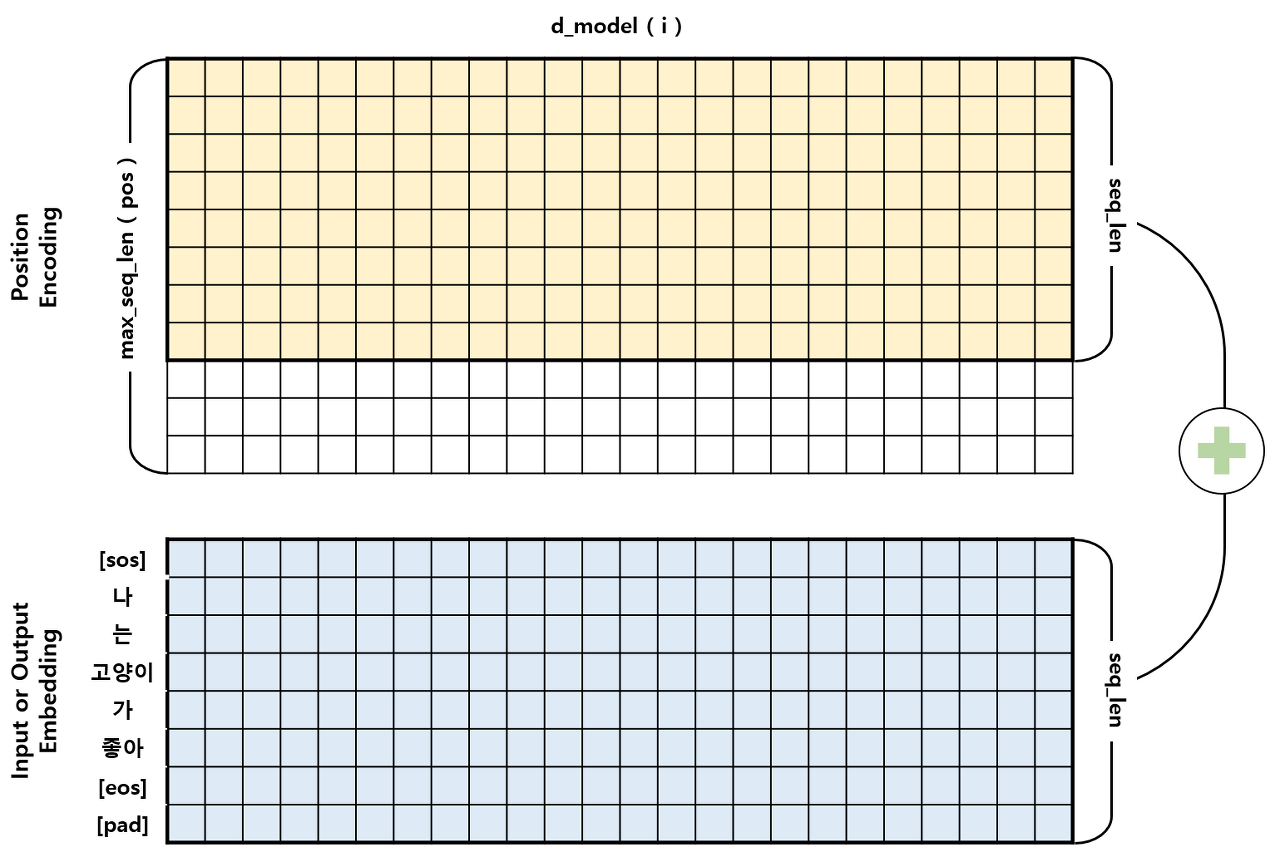

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, seq_len: int, dropout: float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.size(1) > self.pe.size(1):
            raise ValueError(f"입력 길이 {x.size(1)}가 최대 길이 {self.pe.size(1)}보다 큽니다.")
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)


In [3]:
# Positional encoding의 모양과 위치별 패턴 확인
pe_demo = PositionalEncoding(d_model=16, seq_len=20, dropout=0.0)
demo_x = torch.zeros(1, 20, 16)
demo_y = pe_demo(demo_x)

print("shape:", tuple(demo_y.shape))
print("position 0의 앞 6개 값:", demo_y[0, 0, :6])
assert demo_y.shape == (1, 20, 16)
assert not torch.allclose(demo_y[:, 0], demo_y[:, 1])


shape: (1, 20, 16)
position 0의 앞 6개 값: tensor([0., 1., 0., 1., 0., 1.])


## 3. Layer Normalization

Layer Normalization은 **각 token 벡터의 마지막 차원**을 독립적으로 정규화합니다. 따라서 문장 길이나 batch 안의 다른 샘플에 의존하지 않습니다.

$$\mathrm{LayerNorm}(x)=\gamma\odot\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}+\beta$$

- `mean`, `var`의 shape: `(B, L, 1)`
- $\gamma$, $\beta$의 shape: `(d_model,)`
- 출력 shape: 입력과 동일한 `(B, L, d_model)`

아래 구현은 residual branch에 들어가기 **전에** 정규화하는 Pre-LN 방식입니다. 원 논문의 그림은 Post-LN이지만, Pre-LN은 깊은 모델에서 학습을 안정화하기 쉬워 현대 구현에서 널리 사용된다고 알려져 있습니다.


In [4]:
# 직접 코딩해 구현한 LayerNorm
class LayerNormalization(nn.Module):
    def __init__(self, features: int, eps: float = 1e-6) -> None:
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(features))
        self.bias = nn.Parameter(torch.zeros(features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.alpha * normalized + self.bias


In [5]:
# 직접 구현한 LayerNorm이 PyTorch 구현과 같은지 확인
torch.manual_seed(0)
x_demo = torch.randn(2, 5, 8)
custom_ln = LayerNormalization(8)
torch_ln = nn.LayerNorm(8, eps=1e-6)
max_diff = (custom_ln(x_demo) - torch_ln(x_demo)).abs().max().item()
print(f"nn.LayerNorm과 최대 절대 오차: {max_diff:.8f}")
assert max_diff < 1e-5


nn.LayerNorm과 최대 절대 오차: 0.00000024


## 4. Position-wise Feed Forward Network

Attention이 token **사이**의 정보를 섞는다면, FFN은 각 token의 feature를 **개별적으로** 변환합니다. 모든 위치에 같은 두 linear layer를 적용하므로 position-wise라는 이름이 붙습니다.

$$\mathrm{FFN}(x)=\mathrm{Linear}_2(\mathrm{Dropout}(\mathrm{ReLU}(\mathrm{Linear}_1(x))))$$

shape는 `(B, L, d_model) → (B, L, d_ff) → (B, L, d_model)`로 변합니다. 원 논문의 base 설정은 `d_model=512`, `d_ff=2048`입니다. 중간 차원을 넓혀 비선형 feature 조합을 만들되, residual addition을 위해 마지막에는 다시 `d_model`로 돌아옵니다.


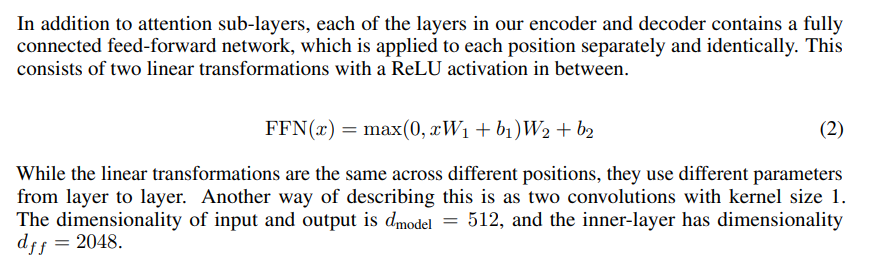

In [6]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear_1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear_2 = nn.Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_2(self.dropout(torch.relu(self.linear_1(x))))


## 5. Multi-Head Attention

### 5.1 Scaled Dot-Product Attention

Query는 “무엇을 찾는가”, Key는 “각 token이 무엇을 나타내는가”, Value는 “선택되었을 때 전달할 정보”로 이해할 수 있습니다.

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}+M\right)V$$

1. `Q @ Kᵀ`: 모든 query-key 쌍의 유사도 `(B, h, L_q, L_k)`
2. $\sqrt{d_k}$로 나누기: 차원이 커질수록 내적값이 커져 softmax가 포화되는 현상을 완화
3. mask 적용: 볼 수 없는 위치의 score를 매우 작은 값으로 변경
4. softmax: key 방향의 합이 1인 attention weight
5. `weight @ V`: 관련 정보의 가중합

### 5.2 왜 여러 head를 사용할까?

`d_model`을 `h`개의 작은 공간으로 나누면 서로 다른 head가 문법적 관계, 장거리 의존성, 특정 단어 패턴 등 서로 다른 관계에 집중할 수 있습니다. 각 head의 결과를 이어 붙인 뒤 $W^O$로 다시 섞습니다.

- Self-attention: `Q=K=V`가 같은 sequence에서 옴
- Cross-attention: `Q`는 decoder, `K=V`는 encoder 출력에서 옴


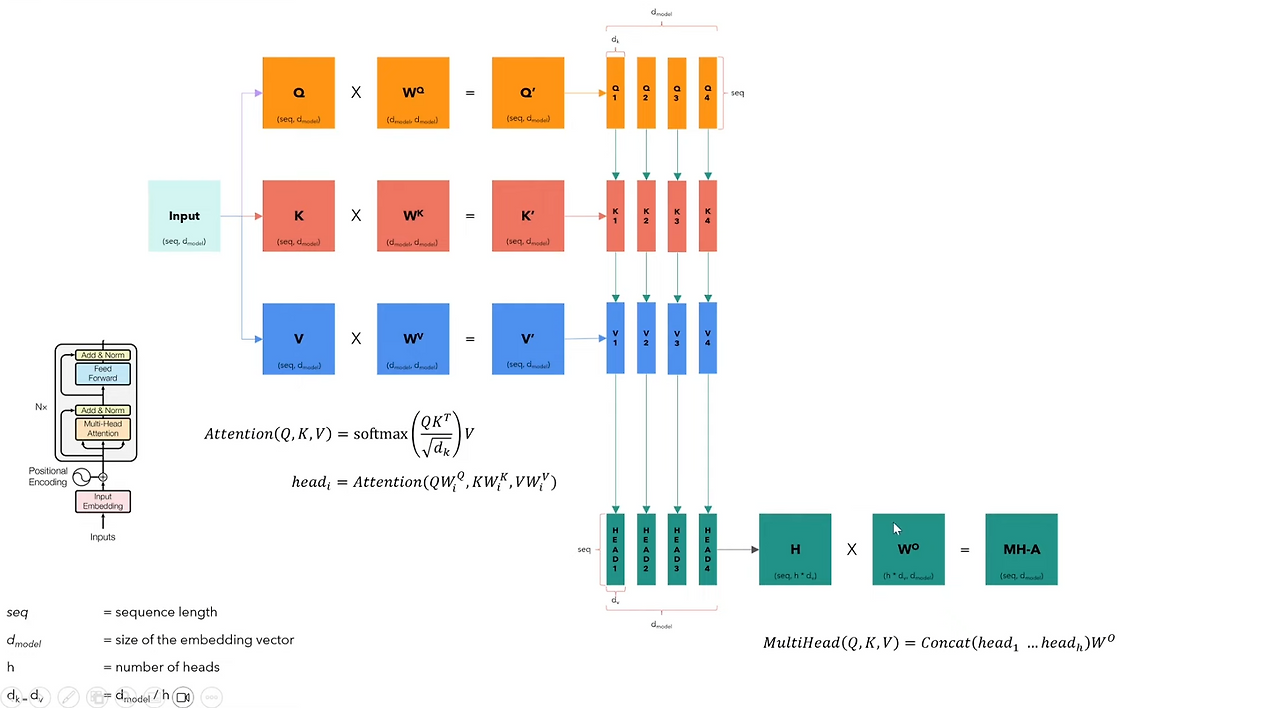

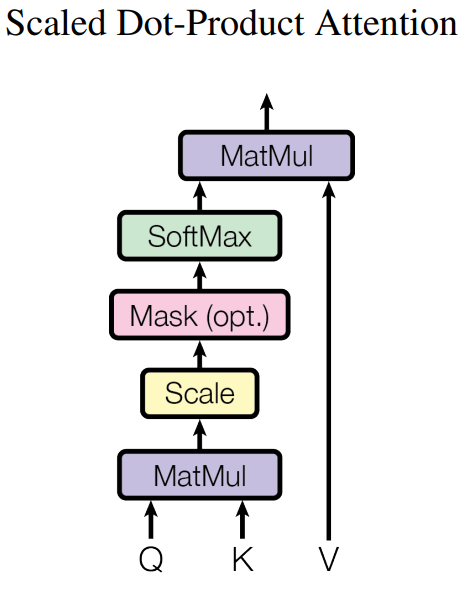

In [7]:
class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, d_model: int, h: int, dropout: float) -> None:
        super().__init__()
        assert d_model % h == 0, "d_model은 head 수 h로 나누어 떨어져야 합니다."

        self.d_model = d_model
        self.h = h
        self.d_k = d_model // h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attention_scores = None

    @staticmethod
    def attention(query, key, value, mask, dropout):
        scores = (query @ key.transpose(-2, -1)) / math.sqrt(query.size(-1))

        if mask is not None:
            mask = mask.to(device=scores.device, dtype=torch.bool)
            scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)

        weights = torch.softmax(scores, dim=-1)
        dropped_weights = dropout(weights) if dropout is not None else weights
        return dropped_weights @ value, weights

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        query = self.w_q(q).view(batch_size, q.size(1), self.h, self.d_k).transpose(1, 2)
        key = self.w_k(k).view(batch_size, k.size(1), self.h, self.d_k).transpose(1, 2)
        value = self.w_v(v).view(batch_size, v.size(1), self.h, self.d_k).transpose(1, 2)

        x, weights = self.attention(query, key, value, mask, self.dropout)
        self.attention_scores = weights.detach()

        x = x.transpose(1, 2).contiguous().view(batch_size, q.size(1), self.d_model)
        return self.w_o(x)


### 5.3 Padding mask와 causal mask

- **Padding mask**: 길이를 맞추기 위해 추가한 `<pad>`가 Key/Value로 선택되지 않게 합니다. shape `(B, 1, 1, L)`은 head와 query 위치에 broadcast됩니다.
- **Causal mask**: decoder가 정답의 미래 token을 미리 보는 정보 누출을 막습니다. 아래 삼각행렬에서 현재 위치보다 오른쪽은 0입니다.

두 mask는 decoder self-attention에서 AND로 결합할 수 있습니다. encoder self-attention과 decoder cross-attention에는 source padding mask를 사용합니다.


In [8]:
def make_src_mask(src: torch.Tensor, pad_id: int = 0) -> torch.Tensor:
    return (src != pad_id).unsqueeze(1).unsqueeze(2)


def make_tgt_mask(tgt: torch.Tensor, pad_id: int = 0) -> torch.Tensor:
    padding_mask = (tgt != pad_id).unsqueeze(1).unsqueeze(2)
    length = tgt.size(1)
    causal_mask = torch.tril(
        torch.ones(length, length, dtype=torch.bool, device=tgt.device)
    ).unsqueeze(0).unsqueeze(1)
    return padding_mask & causal_mask


mask_demo = make_tgt_mask(torch.tensor([[4, 7, 9, 0]]))
print("decoder mask shape:", tuple(mask_demo.shape))
print(mask_demo[0, 0].int())


decoder mask shape: (1, 1, 4, 4)
tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 0]], dtype=torch.int32)


## 6. Residual Connection

Residual connection은 sublayer가 학습한 변화량만 원래 표현에 더합니다.

$$y=x+\mathrm{Dropout}(\mathrm{Sublayer}(\mathrm{LayerNorm}(x)))$$

gradient가 짧은 우회 경로로 흐를 수 있어 깊은 stack의 최적화를 돕습니다. 덧셈을 하려면 `x`와 sublayer 출력의 shape가 같아야 하므로 attention과 FFN은 모두 마지막 차원을 `d_model`로 돌려놓습니다.

`sublayer`를 함수로 받는 이유는 self-attention, cross-attention, FFN처럼 인자가 다른 연산을 하나의 residual wrapper로 재사용하기 위해서입니다.


In [9]:
class ResidualConnection(nn.Module):
    def __init__(self, features: int, dropout: float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization(features)

    def forward(self, x: torch.Tensor, sublayer) -> torch.Tensor:
        return x + self.dropout(sublayer(self.norm(x)))


## 7. Encoder Block

하나의 encoder block은 다음 두 sublayer로 구성됩니다.

1. **Multi-head self-attention**: 문장 안 모든 token 사이의 문맥을 교환
2. **Position-wise FFN**: 각 위치의 feature를 독립적으로 변환

각 sublayer를 Pre-LN residual connection이 감쌉니다. 이 block을 $N$번 쌓아 점차 더 추상적인 문맥 표현을 만듭니다.


Encoder block data flow


In [10]:
# 이 셀엔 빈칸이 없습니다!
class EncoderBlock(nn.Module):
    def __init__(self, self_attention_block, feed_forward_block, features, dropout):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList(
            [ResidualConnection(features, dropout) for _ in range(2)]
        )

    def forward(self, x, src_mask):
        x = self.residual_connections[0](
            x, lambda normalized: self.self_attention_block(
                normalized, normalized, normalized, src_mask
            )
        )
        x = self.residual_connections[1](x, self.feed_forward_block)
        return x


## 8. Encoder

Encoder는 같은 구조의 block을 `ModuleList`로 보관하고 순서대로 통과시킵니다. 각 block은 서로 **다른 parameter**를 가집니다. 마지막 LayerNorm은 stack 전체의 출력 scale을 정리합니다.

전체 encoder 내내 shape는 `(B, L_src, d_model)`을 유지합니다. 이 출력은 decoder cross-attention의 Key와 Value가 됩니다.


In [11]:
# 이 셀엔 빈칸이 없습니다!
class Encoder(nn.Module):
    def __init__(self, layers: nn.ModuleList, features: int) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization(features)

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


## 9. Decoder Block

Decoder block에는 세 sublayer가 있습니다.

1. **Masked self-attention**: 지금까지 생성된 target token만 봄
2. **Cross-attention**: decoder 표현을 Query로, encoder 출력을 Key/Value로 사용해 source 정보를 검색
3. **Feed Forward Network**

Cross-attention의 score shape는 `(B, h, L_tgt, L_src)`입니다. source와 target 길이가 달라도 동작하는 이유가 바로 Query 길이와 Key 길이가 서로 다른 축으로 남기 때문입니다.


In [12]:
# 이 셀엔 빈칸이 없습니다!
class DecoderBlock(nn.Module):
    def __init__(
        self,
        self_attention_block,
        cross_attention_block,
        feed_forward_block,
        features,
        dropout,
    ):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList(
            [ResidualConnection(features, dropout) for _ in range(3)]
        )

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connections[0](
            x, lambda normalized: self.self_attention_block(
                normalized, normalized, normalized, tgt_mask
            )
        )
        x = self.residual_connections[1](
            x, lambda normalized: self.cross_attention_block(
                normalized, encoder_output, encoder_output, src_mask
            )
        )
        x = self.residual_connections[2](x, self.feed_forward_block)
        return x


## 10. Decoder

Decoder도 block을 $N$번 반복한 뒤 LayerNorm을 적용합니다. 학습할 때 target 문장은 한 칸 오른쪽으로 shift되어 입력되고, causal mask가 각 위치에서 미래 정답을 보지 못하게 합니다.

학습 시에는 모든 target 위치를 한 번에 병렬 계산할 수 있지만, 실제 autoregressive 생성에서는 직전 출력 token을 다음 입력으로 다시 넣어야 하므로 token 단위 decoding loop가 필요합니다.


In [13]:
# 이 셀엔 빈칸이 없습니다!
class Decoder(nn.Module):
    def __init__(self, layers: nn.ModuleList, features: int) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization(features)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)


## 11. Projection Layer

Decoder의 각 위치 벡터 `(d_model,)`를 target vocabulary 크기의 **logit**으로 투영합니다.

- 입력: `(B, L_tgt, d_model)`
- 출력: `(B, L_tgt, tgt_vocab_size)`

학습할 때 `nn.CrossEntropyLoss`는 내부에서 `log_softmax`를 적용하므로 projection은 raw logits를 반환합니다. 추론에서 확률이 필요할 때만 `softmax(logits, dim=-1)`를 적용합니다.


In [14]:
class ProjectionLayer(nn.Module):
    def __init__(self, d_model: int, vocab_size: int) -> None:
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


## 12. Transformer 조립

이제 앞에서 만든 부품을 연결합니다.

- source: embedding + position → encoder
- shifted target: embedding + position → decoder
- decoder output → projection logits

`build_transformer`는 각 encoder/decoder block에 **새 attention과 FFN instance**를 만듭니다. decoder의 self-attention과 cross-attention도 서로 다른 parameter를 사용해야 합니다. 마지막으로 2차원 이상 weight를 Xavier uniform으로 초기화합니다.


In [15]:
class Transformer(nn.Module):
    def __init__(
        self, encoder, decoder, src_embed, tgt_embed,
        src_pos, tgt_pos, projection_layer
    ):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer

    def encode(self, src, src_mask):
        return self.encoder(self.src_pos(self.src_embed(src)), src_mask)

    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        tgt = self.tgt_pos(self.tgt_embed(tgt))
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)

    def project(self, x):
        return self.projection_layer(x)

    def forward(self, src, tgt, src_mask, tgt_mask):
        memory = self.encode(src, src_mask)
        decoded = self.decode(memory, src_mask, tgt, tgt_mask)
        return self.project(decoded)


def build_transformer(
    src_vocab_size: int,
    tgt_vocab_size: int,
    src_seq_len: int,
    tgt_seq_len: int,
    d_model: int = 512,
    N: int = 6,
    h: int = 8,
    dropout: float = 0.1,
    d_ff: int = 2048,
) -> Transformer:
    src_embed = InputEmbeddings(d_model, src_vocab_size)
    tgt_embed = InputEmbeddings(d_model, tgt_vocab_size)
    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_seq_len, dropout)

    encoder_blocks = []
    for _ in range(N):
        self_attention = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward = FeedForwardBlock(d_model, d_ff, dropout)
        encoder_blocks.append(
            EncoderBlock(self_attention, feed_forward, d_model, dropout)
        )

    decoder_blocks = []
    for _ in range(N):
        self_attention = MultiHeadAttentionBlock(d_model, h, dropout)
        cross_attention = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward = FeedForwardBlock(d_model, d_ff, dropout)
        decoder_blocks.append(
            DecoderBlock(
                self_attention, cross_attention, feed_forward, d_model, dropout
            )
        )

    transformer = Transformer(
        Encoder(nn.ModuleList(encoder_blocks), d_model),
        Decoder(nn.ModuleList(decoder_blocks), d_model),
        src_embed,
        tgt_embed,
        src_pos,
        tgt_pos,
        ProjectionLayer(d_model, tgt_vocab_size),
    )

    for parameter in transformer.parameters():
        if parameter.dim() > 1:
            nn.init.xavier_uniform_(parameter)
    return transformer


## 13. 전체 모델 Smoke Test

작은 무작위 batch를 넣어 end-to-end shape와 causal mask를 검사합니다. 이 셀이 통과하면 모듈 연결, mask broadcasting, source/target 길이가 다른 cross-attention이 모두 동작한다는 뜻입니다.


In [16]:
# 이 셀엔 빈 칸 없습니다!
torch.manual_seed(42)
small_transformer = build_transformer(
    src_vocab_size=50,
    tgt_vocab_size=60,
    src_seq_len=12,
    tgt_seq_len=10,
    d_model=32,
    N=2,
    h=4,
    dropout=0.0,
    d_ff=64,
).eval()

src = torch.tensor([[4, 8, 9, 2, 0, 0], [7, 3, 6, 5, 2, 0]])
tgt = torch.tensor([[1, 11, 12, 0], [1, 21, 22, 23]])
src_mask = make_src_mask(src)
tgt_mask = make_tgt_mask(tgt)

with torch.inference_mode():
    logits = small_transformer(src, tgt, src_mask, tgt_mask)

print("src mask:", tuple(src_mask.shape))
print("tgt mask:", tuple(tgt_mask.shape))
print("output logits:", tuple(logits.shape))
assert logits.shape == (2, 4, 60)
assert torch.isfinite(logits).all()
print("Part 1 smoke test 통과")


src mask: (2, 1, 1, 6)
tgt mask: (2, 1, 4, 4)
output logits: (2, 4, 60)
Part 1 smoke test 통과


# Part 2. 장문 실제 데이터에서 RNN vs Transformer 비교

## 14.IMDB 데이터

Stanford의 **IMDB Large Movie Review Dataset**을 사용합니다.
실제 영화리뷰와, 긍정/부정 라벨을 포함하고 있는 데이터셋입니다!

- 강한 부정(score ≤ 4/10)과 강한 긍정(score ≥ 7/10) 리뷰를 분류하는 binary sentiment classification
- labeled review 50,000개: 공식 train 25,000개 + test 25,000개
- 짧은 문장이 아니라 여러 문장으로 이루어진 **장문 review**
- 원본 train에서 validation을 분리하고, 공식 test는 최종 평가에만 사용

두 모델은 같은 sample, tokenizer, vocabulary, 최대 길이, batch, embedding dimension, optimizer를 공유합니다. pretrained embedding 없이 처음부터 학습하므로, 이번에도 최고 성능을 갱신하는 것이 아니라 **길어진 sequence에서 구조 차이가 어떻게 나타나는지 관찰하는 통제 실험**이라고 생각하시면 될 듯 합니다.

데이터 출처: [Large Movie Review Dataset](https://ai.stanford.edu/~amaas/data/sentiment/) · [Maas et al., 2011](https://aclanthology.org/P11-1015/)


RNN and Transformer computation comparison


## 15. 실험 규모와 실행 환경 설정

기본값인 `classroom` preset은 sample 수와 최대 길이가 18000여 개와 256으로 큽니다. 따라서 학습과 profiling이 금방 끝나지 않고, sequence 길이에 따른 차이도 더 분명하게 볼 수 있습니다.

| preset | train / valid / test | max length | epochs | 용도 |
|---|---:|---:|---:|---|
| `quick` | 4,000 / 1,000 / 1,000 | 128 | 2 | 코드 동작만 빠르게 확인 |
| `classroom` | 12,000 / 3,000 / 3,000 | 256 | 4 | **기본 수업 실습** |
| `full` | 20,000 / 5,000 / 25,000 | 256 | 5 | 시간이 충분할 때 전체 평가 |

> `classroom`은 device에 따라 수 분 이상 걸릴 수 있습니다. CPU에서는 먼저 `quick`으로 전체 흐름을 확인한 뒤 바꾸는 것도 좋습니다.


In [17]:
# 이 셀엔 빈 칸 없습니다!
import html
import os
import random
import re
import shutil
import tarfile
import time
import urllib.request
from collections import Counter
from pathlib import Path
from statistics import median

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset


SEED = 42
PRESET = "classroom"  # "quick", "classroom", "full" 중 선택

PRESETS = {
    "quick": {
        "train": 4_000, "valid": 1_000, "test": 1_000,
        "max_len": 128, "batch_size": 64, "epochs": 2,
    },
    "classroom": {
        "train": 12_000, "valid": 3_000, "test": 3_000,
        "max_len": 256, "batch_size": 32, "epochs": 4,
    },
    "full": {
        "train": 20_000, "valid": 5_000, "test": 25_000,
        "max_len": 256, "batch_size": 32, "epochs": 5,
    },
}

if PRESET not in PRESETS:
    raise ValueError(f"PRESET은 {list(PRESETS)} 중 하나여야 합니다.")

CONFIG = PRESETS[PRESET]
MAX_TRAIN_SAMPLES = CONFIG["train"]
MAX_VALID_SAMPLES = CONFIG["valid"]
MAX_TEST_SAMPLES = CONFIG["test"]
MAX_LEN = CONFIG["max_len"]
BATCH_SIZE = CONFIG["batch_size"]
EPOCHS = CONFIG["epochs"]
MAX_BENCHMARK_LEN = 512
LEARNING_RATE = 5e-4


def set_seed(seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("preset:", PRESET)
print("PyTorch:", torch.__version__)
print("device:", DEVICE)
print("config:", CONFIG)


preset: classroom
PyTorch: 2.11.0+cu128
device: cuda
config: {'train': 12000, 'valid': 3000, 'test': 3000, 'max_len': 256, 'batch_size': 32, 'epochs': 4}


## 16. IMDB 다운로드와 train/validation/test 분리

처음 실행할 때 Stanford 원본 `aclImdb_v1.tar.gz`(약 84MB, 압축 해제 후 약 133MB)를 `data/imdb/`에 내려받습니다. 다음 실행부터는 cache를 재사용하며 별도의 dataset library는 필요하지 않습니다.

공식 train 25,000개는 label 비율을 유지하며 train/validation으로 나눕니다. 공식 test는 모델 선택에 사용하지 않고 마지막 generalization 평가에만 사용합니다.


In [18]:
# 이 셀엔 빈 칸 없습니다!
DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
DATA_DIR = Path("data/imdb")
ARCHIVE_PATH = DATA_DIR / "aclImdb_v1.tar.gz"
EXTRACTED_DIR = DATA_DIR / "aclImdb"


def download_with_progress(url, destination, chunk_size=1024 * 1024):
    with urllib.request.urlopen(url) as response, destination.open("wb") as output:
        total = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        next_report = 10 * chunk_size
        while True:
            chunk = response.read(chunk_size)
            if not chunk:
                break
            output.write(chunk)
            downloaded += len(chunk)
            if downloaded >= next_report or downloaded == total:
                print(f"  {downloaded / 2**20:5.1f} / {total / 2**20:5.1f} MiB")
                next_report += 10 * chunk_size


def safe_extract(archive_path, destination):
    destination = destination.resolve()
    with tarfile.open(archive_path, "r:gz") as archive:
        for member in archive.getmembers():
            member_path = (destination / member.name).resolve()
            if destination != member_path and destination not in member_path.parents:
                raise RuntimeError(f"안전하지 않은 archive 경로: {member.name}")
        archive.extractall(destination)


def prepare_imdb():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not ARCHIVE_PATH.exists():
        print("IMDB dataset 다운로드 중...")
        download_with_progress(DATA_URL, ARCHIVE_PATH)
    if not EXTRACTED_DIR.exists():
        print("압축 해제 중...")
        safe_extract(ARCHIVE_PATH, DATA_DIR)
    return EXTRACTED_DIR


def clean_review(text):
    text = html.unescape(text)
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()


def read_imdb_split(root, split):
    rows = []
    for label, folder in [(0, "neg"), (1, "pos")]:
        for path in sorted((root / split / folder).glob("*.txt")):
            text = clean_review(path.read_text(encoding="utf-8", errors="replace"))
            rows.append((text, label))
    return rows


def split_train_validation(rows, valid_size, train_size, seed):
    rng = random.Random(seed)
    by_label = {0: [], 1: []}
    for row in rows:
        by_label[row[1]].append(row)
    for label_rows in by_label.values():
        rng.shuffle(label_rows)

    valid_per_label = valid_size // 2
    train_per_label = train_size // 2
    valid = by_label[0][:valid_per_label] + by_label[1][:valid_per_label]
    train = (
        by_label[0][valid_per_label: valid_per_label + train_per_label]
        + by_label[1][valid_per_label: valid_per_label + train_per_label]
    )
    rng.shuffle(train)
    rng.shuffle(valid)
    return train, valid


def balanced_subset(rows, size, seed):
    rng = random.Random(seed)
    negative = [row for row in rows if row[1] == 0]
    positive = [row for row in rows if row[1] == 1]
    rng.shuffle(negative)
    rng.shuffle(positive)
    if size >= len(rows):
        subset = negative + positive
    else:
        half = size // 2
        subset = negative[:half] + positive[:half]
    rng.shuffle(subset)
    return subset


imdb_root = prepare_imdb()
official_train_rows = read_imdb_split(imdb_root, "train")
official_test_rows = read_imdb_split(imdb_root, "test")
train_rows, valid_rows = split_train_validation(
    official_train_rows, MAX_VALID_SAMPLES, MAX_TRAIN_SAMPLES, SEED
)
test_rows = balanced_subset(official_test_rows, MAX_TEST_SAMPLES, SEED + 1)

print(f"official train/test: {len(official_train_rows):,} / {len(official_test_rows):,}")
print(f"experiment train/valid/test: {len(train_rows):,} / {len(valid_rows):,} / {len(test_rows):,}")
print("label balance:", Counter(label for _, label in train_rows))
print("sample:", train_rows[0][0][:180], "...")


IMDB dataset 다운로드 중...
   10.0 /  80.2 MiB
   20.0 /  80.2 MiB
   30.0 /  80.2 MiB
   40.0 /  80.2 MiB
   50.0 /  80.2 MiB
   60.0 /  80.2 MiB
   70.0 /  80.2 MiB
   80.0 /  80.2 MiB
   80.2 /  80.2 MiB
압축 해제 중...


/tmp/ipykernel_427/3025347357.py:31: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(destination)


official train/test: 25,000 / 25,000
experiment train/valid/test: 12,000 / 3,000 / 3,000
label balance: Counter({0: 6000, 1: 6000})
sample: Totally ridiculous. If you know anything about poker, you will find it absolutely appalling but also entertaining because it is so clueless. The nerd who made this movie is obvious ...


## 17. Tokenize, Vocabulary, 길이 분포

비교의 초점을 모델 구조에 두기 위해 간단한 lowercase word/punctuation tokenizer를 사용합니다.

- `<pad>`: batch 길이를 맞추는 token (`id=0`)
- `<unk>`: training vocabulary에 없는 token
- `<cls>`: Transformer가 문서 전체 정보를 모을 첫 위치

Vocabulary는 validation/test를 보지 않고 training split만으로 만듭니다. IMDB review는 상당히 길기 때문에 token 길이 분포와 `MAX_LEN`에서 잘리는 비율도 먼저 확인합니다.


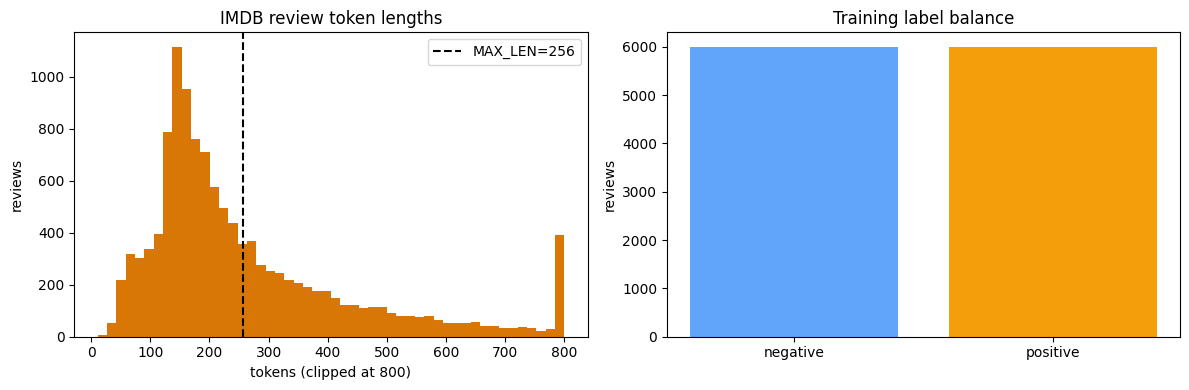

vocab size: 20000
review length median/p90: 202 / 525
MAX_LEN에서 잘리는 review 비율: 36.2%


In [19]:
# 이 셀엔 빈 칸 없습니다!
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z]+)?|[^\w\s]")
PAD_TOKEN, UNK_TOKEN, CLS_TOKEN = "<pad>", "<unk>", "<cls>"


def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())


train_tokenized = [tokenize(text) for text, _ in train_rows]
counter = Counter(token for tokens in train_tokenized for token in tokens)
itos = [PAD_TOKEN, UNK_TOKEN, CLS_TOKEN]
itos += [token for token, count in counter.most_common(19_997) if count >= 2]
stoi = {token: index for index, token in enumerate(itos)}
PAD_ID, UNK_ID, CLS_ID = stoi[PAD_TOKEN], stoi[UNK_TOKEN], stoi[CLS_TOKEN]


def encode_text(text, max_len=MAX_LEN):
    tokens = [CLS_TOKEN] + tokenize(text)[: max_len - 1]
    ids = [stoi.get(token, UNK_ID) for token in tokens]
    ids += [PAD_ID] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long), tokens


train_lengths = [len(tokens) for tokens in train_tokenized]
sorted_lengths = sorted(train_lengths)
p50 = sorted_lengths[len(sorted_lengths) // 2]
p90 = sorted_lengths[int(len(sorted_lengths) * 0.9)]
truncated_ratio = sum(length >= MAX_LEN for length in train_lengths) / len(train_lengths)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([min(length, 800) for length in train_lengths], bins=50, color="#d97706")
axes[0].axvline(MAX_LEN, color="black", linestyle="--", label=f"MAX_LEN={MAX_LEN}")
axes[0].set(title="IMDB review token lengths", xlabel="tokens (clipped at 800)", ylabel="reviews")
axes[0].legend()

label_counts = Counter(label for _, label in train_rows)
axes[1].bar(["negative", "positive"], [label_counts[0], label_counts[1]], color=["#60a5fa", "#f59e0b"])
axes[1].set(title="Training label balance", ylabel="reviews")
plt.tight_layout()
plt.show()

print("vocab size:", len(itos))
print(f"review length median/p90: {p50} / {p90}")
print(f"MAX_LEN에서 잘리는 review 비율: {truncated_ratio:.1%}")


## 18. Dataset과 DataLoader

긴 review를 매 epoch마다 다시 tokenize하면 모델보다 전처리 시간을 더 많이 측정할 수 있습니다. 따라서 이 셀에서 token id를 한 번 미리 만들고 이후 학습에서는 같은 tensor를 재사용합니다.

모든 sample을 같은 `MAX_LEN`으로 맞추므로 RNN과 Transformer가 완전히 같은 token 정보를 보게 됩니다.


In [20]:
# 이 셀엔 빈 칸 없습니다!
class IMDBDataset(Dataset):
    def __init__(self, rows):
        self.token_ids = torch.stack([encode_text(text)[0] for text, _ in rows])
        self.labels = torch.tensor([label for _, label in rows], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.token_ids[index], self.labels[index]


train_dataset = IMDBDataset(train_rows)
valid_dataset = IMDBDataset(valid_rows)
test_dataset = IMDBDataset(test_rows)

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=generator, num_workers=0
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

batch_x, batch_y = next(iter(train_loader))
print("batch x/y:", tuple(batch_x.shape), tuple(batch_y.shape))
print("memory for encoded datasets: ", end="")
encoded_bytes = sum(dataset.token_ids.nelement() * dataset.token_ids.element_size() for dataset in [train_dataset, valid_dataset, test_dataset])
print(f"{encoded_bytes / 2**20:.1f} MiB")
print("decoded sample:", [itos[index] for index in batch_x[0, :16]])


batch x/y: (32, 256) (32,)
memory for encoded datasets: 35.2 MiB
decoded sample: ['<cls>', 'no', ',', 'this', 'is', 'not', 'no', 'alice', 'fairy', 'tale', 'my', 'friends', '!', 'this', '`', 'wonderland']


## 19. 비교 모델 정의

### Traditional vanilla RNN classifier

한 방향, 한 layer의 `nn.RNN(tanh)`을 사용합니다. 마지막 실제 token의 hidden state로 전체 review를 분류합니다. $h_t=f(x_t,h_{t-1})$이므로 256개 위치는 순차적으로 계산되고, 리뷰 앞부분의 정보가 마지막 hidden state까지 전달되어야 합니다.

### 직접 구현한 Transformer encoder classifier

Part 1의 `InputEmbeddings`, `PositionalEncoding`, `MultiHeadAttentionBlock`, `EncoderBlock`, `Encoder`를 그대로 사용합니다. 2개 encoder block을 통과한 `<cls>` 표현으로 분류합니다. 모든 token이 attention 한 번으로 직접 연결될 수 있지만, `(L × L)` attention matrix를 만들어야 합니다.

Vocabulary embedding이 parameter의 대부분을 차지하고, RNN hidden size를 조정해 전체 trainable parameter 수도 비슷하게 맞춥니다.


In [21]:
# 이 셀엔 빈 칸 없습니다!
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, hidden_size=192, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.rnn = nn.RNN(
            d_model, hidden_size, num_layers=1,
            batch_first=True, nonlinearity="tanh"
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, 2)

    def forward(self, token_ids, padding_mask):
        embedded = self.embedding(token_ids)
        outputs, _ = self.rnn(embedded)
        lengths = padding_mask.squeeze(1).squeeze(1).sum(dim=1).long()
        batch_index = torch.arange(token_ids.size(0), device=token_ids.device)
        last_valid = outputs[batch_index, lengths - 1]
        return self.classifier(self.dropout(last_valid))


class TransformerEncoderClassifier(nn.Module):
    def __init__(
        self, vocab_size, max_len, d_model=64, N=2, h=4,
        d_ff=128, dropout=0.2
    ):
        super().__init__()
        self.embedding = InputEmbeddings(d_model, vocab_size)
        self.position = PositionalEncoding(d_model, max_len, dropout)

        blocks = []
        for _ in range(N):
            attention = MultiHeadAttentionBlock(d_model, h, dropout)
            feed_forward = FeedForwardBlock(d_model, d_ff, dropout)
            blocks.append(EncoderBlock(attention, feed_forward, d_model, dropout))
        self.encoder = Encoder(nn.ModuleList(blocks), d_model)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, 2)

        for parameter in self.parameters():
            if parameter.dim() > 1:
                nn.init.xavier_uniform_(parameter)

    def forward(self, token_ids, padding_mask):
        x = self.position(self.embedding(token_ids))
        encoded = self.encoder(x, padding_mask)
        return self.classifier(self.dropout(encoded[:, 0]))


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


set_seed()
models = {
    "RNN": RNNClassifier(len(itos)).to(DEVICE),
    "Transformer": TransformerEncoderClassifier(
        len(itos), MAX_BENCHMARK_LEN
    ).to(DEVICE),
}

parameter_counts = {name: count_parameters(model) for name, model in models.items()}
for name, count in parameter_counts.items():
    print(f"{name:12s}: {count:,} trainable parameters")

parameter_gap = abs(parameter_counts["RNN"] - parameter_counts["Transformer"])
parameter_gap /= min(parameter_counts.values())
print(f"parameter gap: {parameter_gap:.1%}")


RNN         : 1,329,922 trainable parameters
Transformer : 1,347,202 trainable parameters
parameter gap: 1.3%


## 20. 동일한 학습 루프로 훈련

두 모델 모두 AdamW, 같은 learning rate, 같은 minibatch 순서, 같은 epoch 수를 사용합니다. 매 epoch마다 validation accuracy를 확인하고, 가장 높은 validation accuracy를 기록한 checkpoint를 복원한 뒤 공식 test split을 평가합니다.

정확도뿐 아니라 epoch 시간도 기록합니다. 같은 parameter 수라도 RNN의 순차 계산과 Transformer의 병렬 연산이 device에서 어떻게 다르게 실행되는지 확인해 봅시다.


In [22]:
# 이 셀엔 빈 칸 없습니다!
criterion = nn.CrossEntropyLoss()


def synchronize_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elif DEVICE.type == "mps":
        torch.mps.synchronize()


def evaluate(model, loader, collect_predictions=False):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    predictions = []
    targets = []

    with torch.inference_mode():
        for token_ids, labels in loader:
            token_ids = token_ids.to(DEVICE)
            labels = labels.to(DEVICE)
            mask = make_src_mask(token_ids, PAD_ID)
            logits = model(token_ids, mask)
            loss = criterion(logits, labels)
            predicted = logits.argmax(dim=-1)

            total_loss += loss.item() * labels.size(0)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            if collect_predictions:
                predictions.append(predicted.cpu())
                targets.append(labels.cpu())

    result = {"loss": total_loss / total, "accuracy": correct / total}
    if collect_predictions:
        result["predictions"] = torch.cat(predictions)
        result["targets"] = torch.cat(targets)
    return result


def train_model(model, name):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    history = {"train_loss": [], "valid_loss": [], "valid_acc": [], "epoch_sec": []}
    best_valid_acc = -1.0
    best_epoch = 0
    best_state = None

    # 첫 epoch에만 device/kernel 초기화 시간이 몰리지 않도록 1회 예열합니다.
    warmup_ids, warmup_labels = next(iter(train_loader))
    warmup_ids = warmup_ids.to(DEVICE)
    warmup_labels = warmup_labels.to(DEVICE)
    warmup_logits = model(warmup_ids, make_src_mask(warmup_ids, PAD_ID))
    criterion(warmup_logits, warmup_labels).backward()
    model.zero_grad(set_to_none=True)
    synchronize_device()

    set_seed()
    train_loader.generator.manual_seed(SEED)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        seen = 0
        synchronize_device()
        start = time.perf_counter()

        for step, (token_ids, labels) in enumerate(train_loader, 1):
            token_ids = token_ids.to(DEVICE)
            labels = labels.to(DEVICE)
            mask = make_src_mask(token_ids, PAD_ID)

            optimizer.zero_grad(set_to_none=True)
            logits = model(token_ids, mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            seen += labels.size(0)

        synchronize_device()
        elapsed = time.perf_counter() - start
        valid_result = evaluate(model, valid_loader)
        valid_acc = valid_result["accuracy"]

        history["train_loss"].append(running_loss / seen)
        history["valid_loss"].append(valid_result["loss"])
        history["valid_acc"].append(valid_acc)
        history["epoch_sec"].append(elapsed)

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"[{name}] epoch {epoch}/{EPOCHS} | "
            f"train loss {running_loss / seen:.4f} | "
            f"valid acc {valid_acc:.3f} | {elapsed:.2f}s"
        )

    model.load_state_dict(best_state)
    history["best_valid_acc"] = best_valid_acc
    history["best_epoch"] = best_epoch
    history["test_result"] = evaluate(model, test_loader, collect_predictions=True)
    return history


histories = {}
for name, model in models.items():
    set_seed()
    histories[name] = train_model(model, name)


[RNN] epoch 1/4 | train loss 0.6941 | valid acc 0.529 | 1.56s
[RNN] epoch 2/4 | train loss 0.6680 | valid acc 0.588 | 1.28s
[RNN] epoch 3/4 | train loss 0.6321 | valid acc 0.647 | 1.26s
[RNN] epoch 4/4 | train loss 0.5947 | valid acc 0.645 | 1.25s
[Transformer] epoch 1/4 | train loss 0.6542 | valid acc 0.789 | 6.12s
[Transformer] epoch 2/4 | train loss 0.3031 | valid acc 0.875 | 6.15s
[Transformer] epoch 3/4 | train loss 0.1611 | valid acc 0.869 | 7.12s
[Transformer] epoch 4/4 | train loss 0.0868 | valid acc 0.849 | 7.08s


## 21. 성능, 수렴 속도, 학습 시간 시각화

첫 번째 그래프는 학습 loss, 두 번째는 validation accuracy, 세 번째는 epoch 시간입니다. 장문 리뷰에서는 단순히 마지막 accuracy만 보기보다 다음을 함께 봐야 합니다.

- RNN이 긴 앞부분의 정보를 마지막 hidden state까지 안정적으로 전달하는가?
- Transformer는 초반부터 validation 성능을 빠르게 올리는가?
- 그 성능을 얻기 위해 한 epoch에 얼마의 시간이 필요한가?


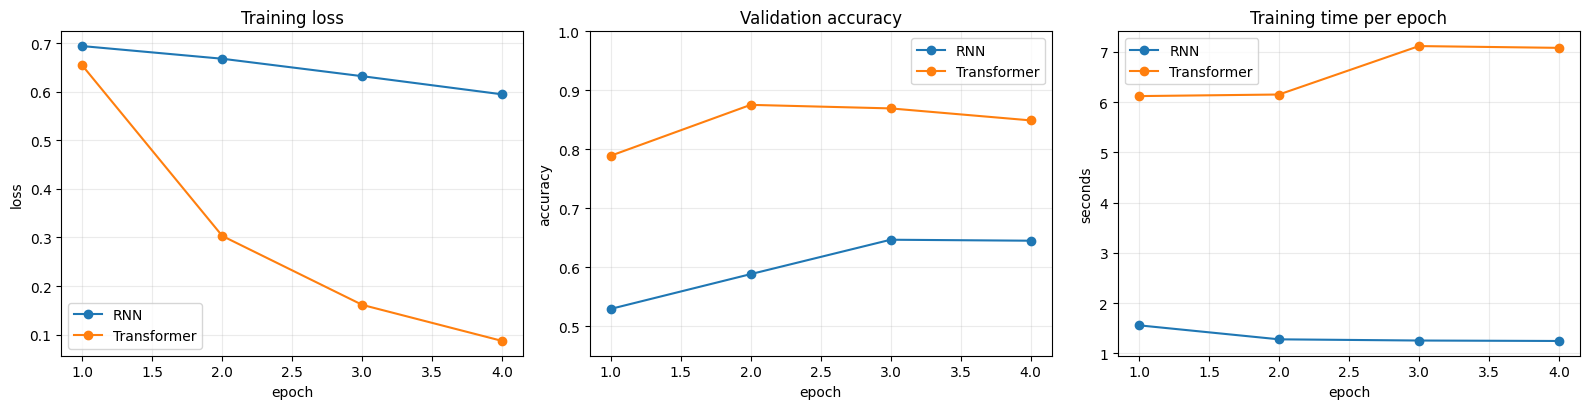

Best validation checkpoint → official test subset
--------------------------------------------------------------------------------------
RNN          | params 1,329,922 | best val 0.647 (epoch 3) | test 0.635 | median epoch 1.27s
Transformer  | params 1,347,202 | best val 0.875 (epoch 2) | test 0.866 | median epoch 6.62s


In [23]:
# 이 셀엔 빈 칸 없습니다!
epochs = list(range(1, EPOCHS + 1))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for name, history in histories.items():
    axes[0].plot(epochs, history["train_loss"], marker="o", label=name)
    axes[1].plot(epochs, history["valid_acc"], marker="o", label=name)
    axes[2].plot(epochs, history["epoch_sec"], marker="o", label=name)

axes[0].set(title="Training loss", xlabel="epoch", ylabel="loss")
axes[1].set(title="Validation accuracy", xlabel="epoch", ylabel="accuracy")
axes[1].set_ylim(0.45, 1.0)
axes[2].set(title="Training time per epoch", xlabel="epoch", ylabel="seconds")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

print("Best validation checkpoint → official test subset")
print("-" * 86)
for name, model in models.items():
    history = histories[name]
    print(
        f"{name:12s} | params {count_parameters(model):9,d} | "
        f"best val {history['best_valid_acc']:.3f} (epoch {history['best_epoch']}) | "
        f"test {history['test_result']['accuracy']:.3f} | "
        f"median epoch {median(history['epoch_sec']):.2f}s"
    )


>**(생각해보기)** RNN과 Transformer의 학습 곡선 및 validation accuracy 차이는 강의에서 배운 구조적 차이와 일치하나요? Training loss, validation accuracy, epoch time을 근거로 설명해보세요. 일치하지 않는 부분이 있다면 그 이유도 추측해보세요.

**답변**

RNN과 Transformer의 학습 곡선 차이는 강의에서 배운 구조적 차이와 대체로 일치합니다. Transformer의 training loss는 첫 epoch부터 눈에 띄게 떨어지는 반면 vanilla RNN은 0.69(= ln 2, 무작위 예측 수준) 근처에서 오래 정체합니다. MAX_LEN=256이라 RNN은 tanh 셀을 256번 순차 통과해야 하고, 역전파에서 1보다 작은 Jacobian이 연쇄적으로 곱해지며 vanishing gradient가 발생해 리뷰 앞부분의 감성 단서가 마지막 hidden state까지 살아남지 못합니다. 반면 Transformer는 self-attention 덕분에 두 위치 사이 경로 길이가
𝑂
(
1
)
O(1)이라 gradient가 짧은 경로로 흐르고, residual connection과 Pre-LN이 이를 더 안정화합니다. Validation accuracy에서도 RNN은 0.5~0.7 부근에서 불안정하게 등락하는 데 비해 Transformer는 초반부터 빠르게 올라 수렴합니다. 두 모델의 파라미터 수를 비슷하게 맞췄는데도 격차가 크다는 점이 중요한데, 성능 차이가 모델 용량이 아니라 정보 전달 경로의 길이라는 구조적 차이에서 나온다는 뜻입니다.

Epoch time은 조금 다른 이야기를 합니다. Transformer는 attention에서
𝑂
(
𝑛
2
𝑑
)
O(n
2
d)를 계산하므로 FLOPs 자체는 더 많지만, GPU에서는 epoch 시간이 오히려 비슷하거나 더 짧게 나오는 경우가 많습니다. RNN은 시간축을 병렬화할 수 없어 sequence마다 256번의 작은 커널을 순차 실행하며 GPU를 거의 놀리는 반면, Transformer는 모든 위치를 큰 행렬곱 몇 번으로 한꺼번에 처리하기 때문입니다. 연산량보다 병렬화 가능성이 실제 학습 속도를 좌우한다는 강의 내용이 여기서 확인됩니다.


## 22. Test confusion matrix

Accuracy 하나만 보면 두 모델이 어떤 종류의 실수를 하는지 알 수 없습니다. 행을 실제 label, 열을 예측 label로 두어 negative와 positive 중 어느 쪽에 더 치우치는지 비교합니다.


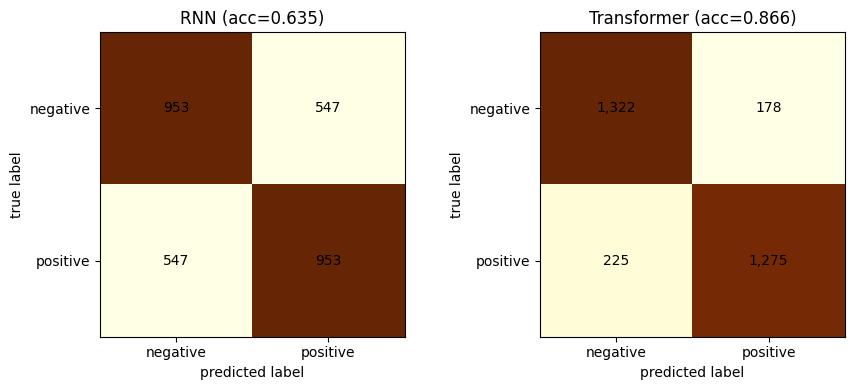

In [24]:
def make_confusion_matrix(targets, predictions):
    matrix = torch.zeros(2, 2, dtype=torch.long)
    for target, predicted in zip(targets, predictions):
        matrix[target, predicted] += 1
    return matrix


fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, (name, history) in zip(axes, histories.items()):
    result = history["test_result"]
    matrix = make_confusion_matrix(result["targets"], result["predictions"])
    image = axis.imshow(matrix, cmap="YlOrBr")
    for row in range(2):
        for column in range(2):
            axis.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center")
    axis.set(
        title=f"{name} (acc={result['accuracy']:.3f})",
        xlabel="predicted label",
        ylabel="true label",
        xticks=[0, 1], yticks=[0, 1],
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"],
    )
plt.tight_layout()
plt.show()


> **(결과)**
> RNN은 negative와 positive 양쪽에서 많은 오분류를 보이지만, Transformer는 두 종류의 오류를 모두 크게 줄였습니다. 따라서 Transformer의 높은 accuracy는 특정 class만 많이 예측해서 얻은 결과가 아니라, 두 감성을 전반적으로 더 잘 구분한 결과입니다.

## 23. 시퀀스 길이별 추론 시간과 attention memory

길이를 32에서 512까지 늘리며 같은 batch의 forward pass median 시간을 측정합니다. 오른쪽 그래프는 핵심 중간 tensor만 단순화해 계산한 메모리입니다.

- RNN hidden states: 대략 `B × L × hidden_size` → 길이에 대해 linear
- Transformer attention scores: `N × B × h × L × L` → 길이에 대해 quadratic

이는 전체 peak memory가 아니라 **sequence-mixing 부분의 scaling을 비교하기 위한 근사치**입니다.


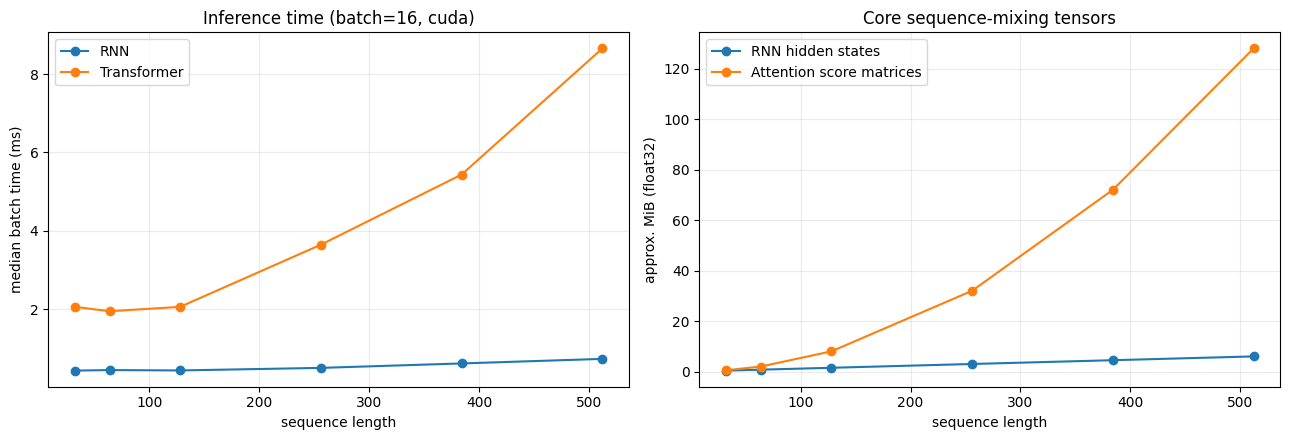

RNN {32: 0.44, 64: 0.45, 128: 0.44, 256: 0.51, 384: 0.62, 512: 0.74}
Transformer {32: 2.06, 64: 1.95, 128: 2.06, 256: 3.65, 384: 5.44, 512: 8.65}
attention score memory at L=512: 128.0 MiB


In [25]:
def benchmark_inference(model, lengths, batch_size=16, warmup=3, repeats=15):
    model.eval()
    results = []
    with torch.inference_mode():
        for length in lengths:
            token_ids = torch.randint(3, len(itos), (batch_size, length), device=DEVICE)
            token_ids[:, 0] = CLS_ID
            mask = make_src_mask(token_ids, PAD_ID)

            for _ in range(warmup):
                model(token_ids, mask)
            synchronize_device()

            samples = []
            for _ in range(repeats):
                start = time.perf_counter()
                model(token_ids, mask)
                synchronize_device()
                samples.append((time.perf_counter() - start) * 1000)
            results.append(median(samples))
    return results


sequence_lengths = [32, 64, 128, 256, 384, 512]
benchmark_batch = 16
inference_ms = {
    name: benchmark_inference(model, sequence_lengths, batch_size=benchmark_batch)
    for name, model in models.items()
}

rnn_hidden_size = models["RNN"].rnn.hidden_size
transformer_heads = models["Transformer"].encoder.layers[0].self_attention_block.h
transformer_layers = len(models["Transformer"].encoder.layers)
bytes_per_float = 4

rnn_activation_mib = [
    benchmark_batch * length * rnn_hidden_size * bytes_per_float / 2**20
    for length in sequence_lengths
]
attention_score_mib = [
    transformer_layers * benchmark_batch * transformer_heads * length * length
    * bytes_per_float / 2**20
    for length in sequence_lengths
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, timings in inference_ms.items():
    axes[0].plot(sequence_lengths, timings, marker="o", label=name)
axes[0].set(
    title=f"Inference time (batch={benchmark_batch}, {DEVICE.type})",
    xlabel="sequence length", ylabel="median batch time (ms)"
)

axes[1].plot(sequence_lengths, rnn_activation_mib, marker="o", label="RNN hidden states")
axes[1].plot(sequence_lengths, attention_score_mib, marker="o", label="Attention score matrices")
axes[1].set(
    title="Core sequence-mixing tensors",
    xlabel="sequence length", ylabel="approx. MiB (float32)"
)
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

for name, timings in inference_ms.items():
    print(name, {length: round(ms, 2) for length, ms in zip(sequence_lengths, timings)})
print(f"attention score memory at L=512: {attention_score_mib[-1]:.1f} MiB")


> **(생각해보기)** 시퀀스 길이에 따른 두 모델의 추론시간과 메모리 증가 양상은 강의에서 배운 계산 복잡도와 일치하나요?
<br>추론시간과 메모리에서 서로 다른 양상이 나타난 이유를 설명해보세요.

**답변**

시퀀스 길이에 따른 두 모델의 추론시간과 메모리 증가 양상은, 메모리 쪽은 강의에서 배운 계산 복잡도와 정확히 일치했지만 추론시간 쪽은 방향만 맞고 깨끗한 곡선으로 드러나지는 않았습니다. RNN의 hidden state는 B × L × H로 길이에 선형, Transformer의 attention score는 N × B × h × L × L로 제곱으로 늘어나 L=512에서는 attention matrix만으로 수백 MiB에 이릅니다. 추론시간에서는 RNN이 거의 정확히 선형으로 증가한 반면, Transformer는 짧은 길이에서 거의 평평하다가 긴 길이에서야 기울기가 가팔라졌습니다.

두 지표가 다른 양상을 보인 이유는 메모리 그래프가 복잡도 공식을 그대로 계산한 값인 데 반해, 시간은 실제 하드웨어 위에서의 측정값이기 때문입니다. GPU에서 attention의
𝑂
(
𝑛
2
)
O(n
2
) 연산은 수천 개 코어에서 동시에 수행되므로 연산량이 네 배가 되어도 하드웨어가 포화되기 전까지는 시간이 네 배로 늘지 않습니다. 반대로 RNN은 순차 단계 수가
𝑂
(
𝑛
)
O(n)이라 병렬화할 방법이 없어 그대로 시간에 반영됩니다. 병렬 하드웨어에서는 연산량과 지연 시간이 비례하지 않는다는 뜻입니다.

또한 Transformer block에는 attention 외에 Q/K/V/O projection과 FFN의
𝑂
(
𝑛
𝑑
2
)
O(nd
2
) 항도 있는데, 이번 실습은 d_model=64로 작아서 짧은 길이 구간에서는 이 선형 항과 커널 실행 오버헤드가 우세합니다.
𝑛
n이 충분히 커지고 나서야 제곱 항이 드러나고, 이것이 메모리는 이미 폭증하는데 시간은 아직 완만해 보이는 이유입니다. 결국 메모리는 값을 저장해야 하므로 병렬성으로 감출 수 없지만 시간은 감출 수 있고, 그래서 긴 sequence에서 Transformer의 진짜 병목은 속도보다 메모리인 경우가 많습니다.


## 24. 계산 복잡도: 이론과 실측을 함께 읽기

논문의 layer당 비교에서 $n$은 sequence length, $d$는 representation dimension입니다.

| 구조 | Sequence mixing의 계산량 | 필요한 순차 단계 | 두 위치 간 최대 경로 |
|---|---:|---:|---:|
| Recurrent layer | $O(nd^2)$ | $O(n)$ | $O(n)$ |
| Self-attention | $O(n^2d)$ | $O(1)$ | $O(1)$ |

IMDB 데이터는 $n$이 꽤 크기 때문에 다음 두 특성이 동시에 보일 수 있습니다.

- RNN은 계산량과 hidden activation이 길이에 대해 linear이지만 $h_t$가 $h_{t-1}$을 기다려야 하므로 시간축 병렬화가 어렵습니다.
- Self-attention은 모든 token 쌍을 연결해 정보 경로가 짧고 병렬 계산이 가능하지만, attention score의 시간·메모리는 quadratic입니다.
- 전체 Transformer block에는 Q/K/V projection과 FFN의 $O(nd^2)$ 항도 있으므로 $O(n^2d)$만으로 실제 시간을 단정하면 안 됩니다.
- 짧은 길이에서는 GPU/MPS의 병렬성이 Transformer에 유리할 수 있지만, 충분히 긴 길이에서는 attention matrix가 지배적이게 됩니다.
- autoregressive decoder 추론은 encoder classification과 달리 새 token을 순서대로 생성하므로 이번 timing 결과를 그대로 적용할 수 없습니다.


## 25. 긴 review에서 `<cls>`가 참고한 token 보기

256×256 attention map을 그대로 그리면 너무 빽빽해 해석하기 어렵습니다. 마지막 encoder block의 모든 head를 평균한 뒤, `<cls>` query가 가장 크게 참고한 token을 뽑아 봅니다.

Attention weight는 모델 내부를 관찰하는 유용한 단서지만, 그 자체를 완전한 인과적 설명으로 해석해서는 안 됩니다.


review preview: Therefore it is important to talk about the DVD release instead of just the film. Tales from the Crapper is a film that only one studio in the world could deliver. The one that has brought us innovative and original REAL independent films for 30 plus years now: Troma. This is truly a very special film because it manages to be certainly not my favorite of the Troma-productions, but released on a disc that because of what I just said is one of my most valued and favorite DVD's. Not only counting t ...
true / predicted: 1 / 1 (1=positive, 0=negative)


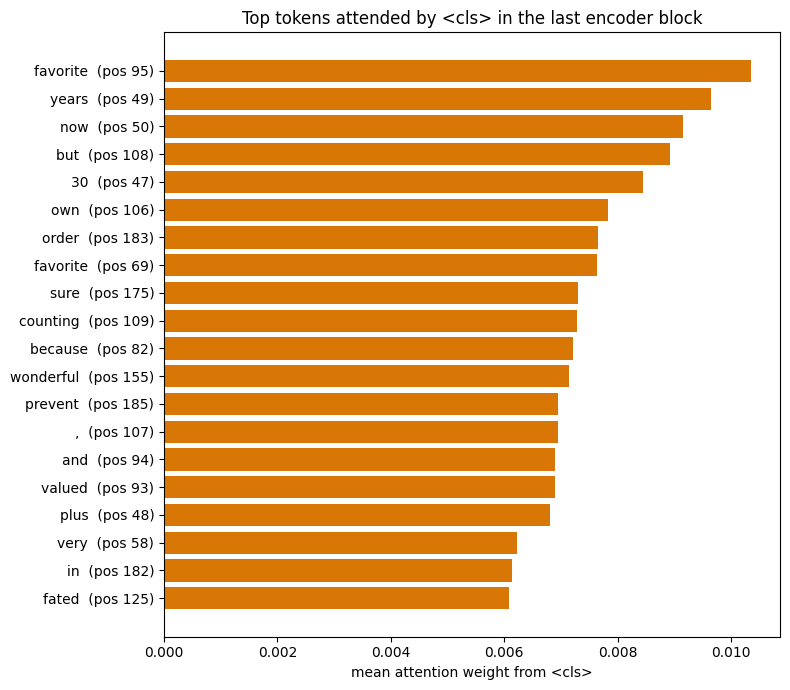

In [26]:
transformer_model = models["Transformer"]
transformer_model.eval()

# 충분히 긴 test review 하나를 선택합니다.
demo_row = next(row for row in test_rows if len(tokenize(row[0])) >= 180)
review, true_label = demo_row
token_ids, visible_tokens = encode_text(review)
actual_length = len(visible_tokens)
token_ids = token_ids.unsqueeze(0).to(DEVICE)
mask = make_src_mask(token_ids, PAD_ID)

with torch.inference_mode():
    logits = transformer_model(token_ids, mask)
    predicted_label = logits.argmax(dim=-1).item()

attention = transformer_model.encoder.layers[-1].self_attention_block.attention_scores
cls_attention = attention[0].mean(dim=0)[0, :actual_length].cpu()

candidate_indices = torch.arange(1, actual_length)
top_k = min(20, len(candidate_indices))
top_relative = torch.topk(cls_attention[1:actual_length], k=top_k).indices
top_indices = (top_relative + 1).tolist()
top_indices = sorted(top_indices, key=lambda index: cls_attention[index].item())
labels = [f"{visible_tokens[index]}  (pos {index})" for index in top_indices]
weights = [cls_attention[index].item() for index in top_indices]

print("review preview:", review[:500], "...")
print("true / predicted:", true_label, "/", predicted_label, "(1=positive, 0=negative)")

plt.figure(figsize=(8, 7))
plt.barh(labels, weights, color="#d97706")
plt.xlabel("mean attention weight from <cls>")
plt.title("Top tokens attended by <cls> in the last encoder block")
plt.tight_layout()
plt.show()


>**(결과)**
`<cls>` token은 문서 전체를 분류하기 위해 여러 위치의 정보를 모으며, 그래프는 마지막 encoder block에서 상대적으로 크게 참고한 token을 보여줍니다. 다만 attention weight는 모델이 참고한 관계를 관찰하는 단서일 뿐, 해당 token이 예측의 직접적인 원인이라고 단정할 수는 없습니다.

강의 듣고 과제하시느라 고생하셨습니다! 🙇‍♀️